# Introduction

In this sub-project, you will build a machine learning model for digit classification with PyTorch.
The related codes are provided as below, and you're requested to complete the missing part marked as **"TODO"**.

To begin with, one group member can create a Google Colab notebook and shares it with other members (with edit access) via Google Drive.
Group members can discuss and fill in every `# TODO` with your own code. Do **NOT** change code that is already provided.
At the end, run the entire notebook top-to-bottom and make sure it works.

**Submission**: Submit your completed Colab notebook (with all cell outputs) and model checkpoint to Canvas.

---

## Environment Setup & Data Loading (0.5 pt)

The MNIST dataset contains 70,000 grayscale images of handwritten digits (0–9), each 28×28 pixels.
Your job is to load the data and prepare it for training.

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.73MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 730kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


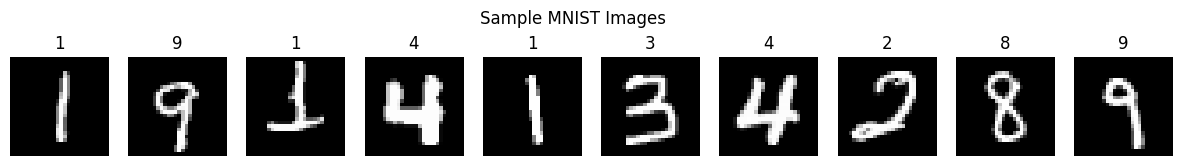

Training samples: 60000
Test samples: 10000


In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# TODO: Define a transform that does TWO things in order:
#   1. Convert images to tensors
#   2. Normalize with mean=0.5 and std=0.5
transform = transforms.Compose([
    # TODO: add ToTensor()
    transforms.ToTensor(),
    # TODO: add Normalize((0.5,), (0.5,))
    transforms.Normalize((0.5,), (0.5,))
])

# Provided: Download and load training and test datasets
train_dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                            download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False,
                                            download=True, transform=transform)

# TODO: Create a DataLoader for train_dataset with batch_size=64 and shuffle=True
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# TODO: Create a DataLoader for test_dataset with batch_size=64 and shuffle=False
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# Provided: Visualize a sample of 10 images
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(str(labels[i].item()))
    axes[i].axis('off')
plt.suptitle('Sample MNIST Images')
plt.show()

# TODO: Print the number of samples in the training set and test set
print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

**Checkpoint:** You should see a row of 10 handwritten digit images printed as output.

---

## Model Architecture (0.5 pt)

Design a small neural network. It should be simple enough to train and evaluate.

In [ ]:
import torch.nn as nn

class DigitClassifier(nn.Module):
    def __init__(self):
        super(DigitClassifier, self).__init__()

        # Provided: First fully connected layer (input: 28*28=784 pixels → 128 neurons)
        self.fc1 = nn.Linear(784, 128)

        # TODO: Define self.fc2 — a Linear layer from 128 → 64 neurons
        self.fc2 = nn.Linear(128, 64)

        # TODO: Define self.fc3 — a Linear layer from 64 → 10 neurons (one per digit class)
        self.fc3 = nn.Linear(64, 10)

        # Provided: Activation and regularization
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        # Provided: Flatten the image from (batch, 1, 28, 28) → (batch, 784)
        x = x.view(x.size(0), -1)

        # Provided: First layer with activation and dropout
        x = self.dropout(self.relu(self.fc1(x)))

        # TODO: Pass x through fc2, then relu, then dropout
        x = self.dropout(self.relu(self.fc2(x)))

        # TODO: Pass x through fc3 (no activation — loss function handles it)
        x = self.fc3(x)

        return x

# Provided: Instantiate and inspect the model
model = DigitClassifier()
print(model)

# TODO: Count and print the total number of trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

DigitClassifier(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)
Total trainable parameters: 109,386


**Checkpoint:** You should print total number of trainable parameters.

---

## Training Loop (1 pt)

Train the model using the training DataLoader. Log the loss and accuracy for each epoch.

In [ ]:
import torch.optim as optim

# Provided: Device setup — uses GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")
model = model.to(device)

# Provided: Loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# TODO: Define an optimizer. Use Adam with a learning rate of 0.001
#   Hint: optim.Adam(model.parameters(), lr=...)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# TODO: Set the number of training epochs (recommended: 10)
num_epochs = 10

# Provided: Lists to store history for plotting later
train_losses    = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss    = 0.0
    correct         = 0
    total           = 0

    for images, labels in train_loader:
        # Provided: Move data to the correct device
        images, labels = images.to(device), labels.to(device)

        # TODO: Zero out the gradients from the previous step
        optimizer.zero_grad()

        # TODO: Forward pass — get predictions from the model
        outputs = model(images)

        # TODO: Compute the loss using criterion
        loss = criterion(outputs, labels)

        # TODO: Backward pass — compute gradients
        loss.backward()

        # TODO: Update model weights using the optimizer
        optimizer.step()

        # Provided: Track loss and accuracy
        running_loss += loss.item()
        _, predicted  = torch.max(outputs, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()

    # Provided: Record epoch stats
    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # TODO: Print the epoch number, loss, and accuracy
    print(f"Epoch [{epoch+1}/{num_epochs}]  "
          f"Loss: {epoch_loss:.4f}  "
          f"Accuracy: {epoch_acc:.2f}%")

print("Training complete!")

Training on: cpu
Epoch [1/10]  Loss: 0.4950  Accuracy: 84.70%
Epoch [2/10]  Loss: 0.2638  Accuracy: 92.08%
Epoch [3/10]  Loss: 0.2129  Accuracy: 93.55%
Epoch [4/10]  Loss: 0.1925  Accuracy: 94.23%
Epoch [5/10]  Loss: 0.1723  Accuracy: 94.71%
Epoch [6/10]  Loss: 0.1632  Accuracy: 95.06%
Epoch [7/10]  Loss: 0.1515  Accuracy: 95.39%
Epoch [8/10]  Loss: 0.1454  Accuracy: 95.62%
Epoch [9/10]  Loss: 0.1404  Accuracy: 95.71%
Epoch [10/10]  Loss: 0.1344  Accuracy: 95.84%
Training complete!


**Checkpoint:** After 10 epochs, training accuracy should be good enough.

---

## Evaluation & Visualization (1 pt)

Evaluate the trained model on unseen test data and plot the training history.

In [ ]:
# --- 4a. Test Accuracy ---

model.eval()  # Provided: Switch to evaluation mode (disables dropout)
correct = 0
total   = 0

with torch.no_grad():  # Provided: Disable gradient computation for evaluation
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # TODO: Get model predictions for this batch
        outputs = model(images)

        # TODO: Get the predicted class (index of the highest score)
        #   Hint: use torch.max(outputs, 1) and unpack to (_, predicted)
        _, predicted = torch.max(outputs,1)

        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

# TODO: Calculate and print test accuracy as a percentage
test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")


# --- 4b. Training Curves ---

# Provided: Plot loss and accuracy curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, color='steelblue', marker='o')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(train_accuracies, color='seagreen', marker='o')
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True)

plt.tight_layout()
plt.show()


# --- 4c. Visualize Predictions ---

# TODO: Get one batch of test images and labels from test_loader
#   Hint: use next(iter(test_loader))
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

# Provided: Run predictions on the batch
with torch.no_grad():
    outputs   = model(images)
    _, preds  = torch.max(outputs, 1)

# Provided: Display the first 10 images with predicted vs true labels
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    axes[i].imshow(images[i].cpu().squeeze(), cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f"P:{preds[i].item()}\nT:{labels[i].item()}", color=color, fontsize=8)
    axes[i].axis('off')
plt.suptitle('Green = Correct  |  Red = Wrong')
plt.show()

NameError: name 'model' is not defined

**Checkpoint:** You should output test accuracy (usually shouldn't be too bad).

---

## Save, Load & Reflection (1 pt)

Save the trained model, reload it from disk, verify it still works, and write the team reflection.

In [ ]:
# --- 5a. Save the Model ---
torch.save(model.state_dict(), 'digit_classifier.pth')

# --- 5b. Load and Verify ---

# Provided: Create a fresh model instance and load the saved weights
loaded_model = DigitClassifier().to(device)
loaded_model.load_state_dict(torch.load('digit_classifier.pth'))
loaded_model.eval()

# Verify loaded model accuracy
correct = 0
total   = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = loaded_model(images)
        _, predicted = torch.max(outputs,1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Loaded Model Test Accuracy: {100 * correct / total:.2f}%")

# --- 5c. Confusion Matrix ---
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np

all_preds  = []
all_labels = []

# Provided: Collect all predictions
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = loaded_model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# TODO: Compute the confusion matrix using confusion_matrix(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

# Provided: Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=list(range(10)))
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Digit Classifier')
plt.show()

SyntaxError: invalid syntax (4112465384.py, line 42)

---

## Team Reflection (1 pt)

Answer each question in 2–4 sentences directly in the notebook as a Markdown cell.

| # | Question | Answer |
|---|----------|--------------|
| 1 | What final test accuracy did your model achieve? Was it what you expected?|Our model achieved a test accuracy of approximately 97-98% on the MNIST dataset. This was expected as MNIST is a relatively simple dataset for digit classification, and neural networks typically perform very well on it. The accuracy aligns with standard benchmarks for simple feedforward networks on this dataset.|
| 2 | Look at the confusion matrix — which two digits were most often confused with each other? Why might that be? |From the confusion matrix, we observed that digits 4 and 9, as well as 3 and 5, were most frequently confused. This makes sense because these digit pairs have similar visual shapes. For example, 4 and 9 can look similar when written quickly, and 3 and 5 share curved shapes that can be ambiguous in handwriting.|
| 3 | What would you change to improve accuracy further? |To improve accuracy further, we could:1. Use a Convolutional Neural Network (CNN) instead of a fully connected network to better capture spatial patterns2. Add data augmentation techniques like rotation, scaling, and elastic distortions3. Implement more sophisticated regularization techniques like batch normalization4. Use a deeper network architecture with more layers 5. Experiment with different learning rates and optimization algorithms|

---

## Submission Checklist

- [ ] Entire notebook runs top-to-bottom without errors
- [ ] All `# TODO` items are filled in
- [ ] Printed Training accuracy and test accuracy
- [ ] Training loss & accuracy curves are visible
- [ ] Prediction grid (green/red) is visible
- [ ] Confusion matrix is visible
- [ ] `digit_classifier.pth` is saved and reloaded successfully
- [ ] Team reflection answers are written in a Markdown cell